# Практика. Экосистема

Цель занятия — «потрогать руками» данные, попытаться понять закономерности, сформулировать гипотезы и, если повезёт, подтвердить их (или опровергнуть). Анализ данных — это на 90% проверка гипотез.

>#### Задание
Загрузите библиотеки pandas, matplotlib.pyplot и seaborn.

In [1]:
import pandas as pd   
import matplotlib.pyplot as plt 
import seaborn as sns 
sns.set(style = 'whitegrid', palette = 'pastel')

>#### Задание
Загрузите датасет housing из папки data.

In [2]:
df = pd.read_csv('data/housing.csv')
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


Каждая строка в этом датасете представляет усреднённую статистику по одному блоку переписи (census block group) в Калифорнии. Блок переписи — это небольшая географическая единица, используемая Бюро переписи населения США.
- Обычно содержит от 600 до 3000 человек.
- Является административно-статистической единицей для сбора данных.
- В одном городе/районе может быть множество таких блоков.

Структура датасета такова:
- MedInc — медианный доход жителей,
- HouseAge — средний возраст домов в блоке,
- AveRooms — среднее количество комнат,
- AveBedrms — среднее количество спален,
- Population — население блока,
- AveOccup — средняя заполняемость домов,
- Latitude — широта,
- Longitude — долгота (отрицательные значения, потому что это западное полушарие),
- MedHouseVal — целевая переменная: медианная стоимость дома (в сотнях тысяч долларов).

>#### Задание
>Просмотрите информацию о данных при помощи метода `info()`, выведите статистики данных при помощи метода `describe()`. 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


>#### Задание
Выведите в виде отдельного датафрейма таблицу, содержащую записи о блоках с медианной ценой в пределах интерквартильного размаха, и запишите этот датафрейм в файл housing_Q1_Q3.

In [6]:
df.loc[(df['MedHouseVal'] > df.describe()['MedHouseVal']['25%']) &
       (df['MedHouseVal'] < df.describe()['MedHouseVal']['75%'])]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611
11,3.2705,52.0,4.772480,1.024523,1504.0,2.049046,37.85,-122.26,2.418
12,3.0750,52.0,5.322650,1.012821,1098.0,2.346154,37.85,-122.26,2.135
...,...,...,...,...,...,...,...,...,...
20574,1.9327,10.0,5.789474,1.078947,898.0,3.938596,38.57,-121.92,1.938
20575,3.7500,38.0,5.275229,0.981651,259.0,2.376147,38.72,-121.90,1.875
20581,3.1534,20.0,5.444976,1.057416,459.0,2.196172,38.83,-122.21,1.234
20583,3.8750,31.0,4.416667,0.880952,208.0,2.476190,38.73,-122.00,1.375


>#### Задание
Выведите в виде отдельного датафрейма таблицу, содержащую данные о географическом расположении блоков и их медианной стоимости. Сохраните эту таблицу в файл housing_geography.

In [6]:
# Код

>#### Задание
Выясните, как распределены блоки по территории штата. Где находятся районы с наиболее плотной застройкой? Где находятся наиболее дорогие дома?

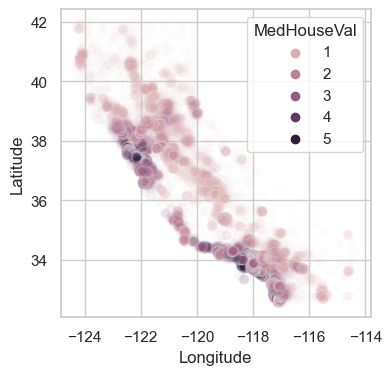

In [8]:
plt.figure(figsize=(4, 4))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='MedHouseVal', alpha=0.05, s=50)
# plt.title('Связь возраста, стоимости билета и выживаемости')
# plt.xlabel('Возраст')
# plt.ylabel('Стоимость билета')
# plt.yscale('log') # Использована логарифмическая шкала для наглядности, так как были очень дорогие билеты.
plt.show()

>#### Задание
Постройте гистограммы распределений каждого из признаков. Какие особенности наблюдаются? Как их можно объяснить?

In [8]:
# Код

>#### Задание
Верно ли, что артефакты по возрасту домов и их стоимости определяются ошибками системы сбора данных? Подтвердите или опровергните эту гипотезу при помощи диаграммы рассеяния `scatterplot`.

In [9]:
# Код

>#### Задание
Удалите артефакты из данных и проведите повторный анализ распределений каждого из признаков.

In [10]:
# Код

>#### Задание
Выясните, какие признаки оказывают наибольшее влияние на медианную цену. Подсказка: для этого тоже можно использовать `scatterplot`.

In [11]:
# Код

>#### Задание
Постройте тепловую карту попарных корреляций для всех признаков датафрейма. Используйте синтаксическую конструкцию:
>```python 
>corr_matrix = data.corr()
>sns.heatmap(corr_matrix)
>```
Как объяснить тот факт, что географическая широта сильно коррелирует с географической долготой?

In [12]:
# Код

# Домашнее задание

>#### Задание
Загрузите датасет wine из папки data.

Wine dataset — классический набор данных, используемый в машинном обучении для задач классификации. Он содержит результаты химического анализа вин, выращенных в трёх разных регионах Италии, и полученных из трёх различных сортов винограда. 

Список признаков
- alcohol — содержание алкоголя в вине. 
- malic acid — количество яблочной кислоты (тип органической кислоты). 
- ash — содержание золы в вине. 
- alcalinity of ash — щелочность золы. 
- magnesium — количество магния в вине. 
- total phenols — общее содержание фенолов. 
- flavanoids — концентрация флавоноидов (тип растительных пигментов). 
- nonflavanoid phenols — концентрация нефлавоноидных фенольных соединений. 
- proanthocyanins — концентрация проантоцианов (тип флавоноидов). 
- color intensity — интенсивность цвета вина. 
- hue — оттенок или цветовая гамма вина. 
- od280/od315 of diluted wines — оптическая плотность разбавленных вин, мера плотности цвета. 
- proline — концентрация пролина (аминокислоты). 
- class — регион происхождения вина (0, 1 или 2)

>#### Задание
>1) Проведите предварительный просмотр информации о данных и их статистик.
>2) Постройте гистрограммы признаков. Вопрос: являются ли классы регионов 0, 1 и 2 сбалансированными?
>3) Определите признак при помощи которого разделяются классы 0 и 2. 